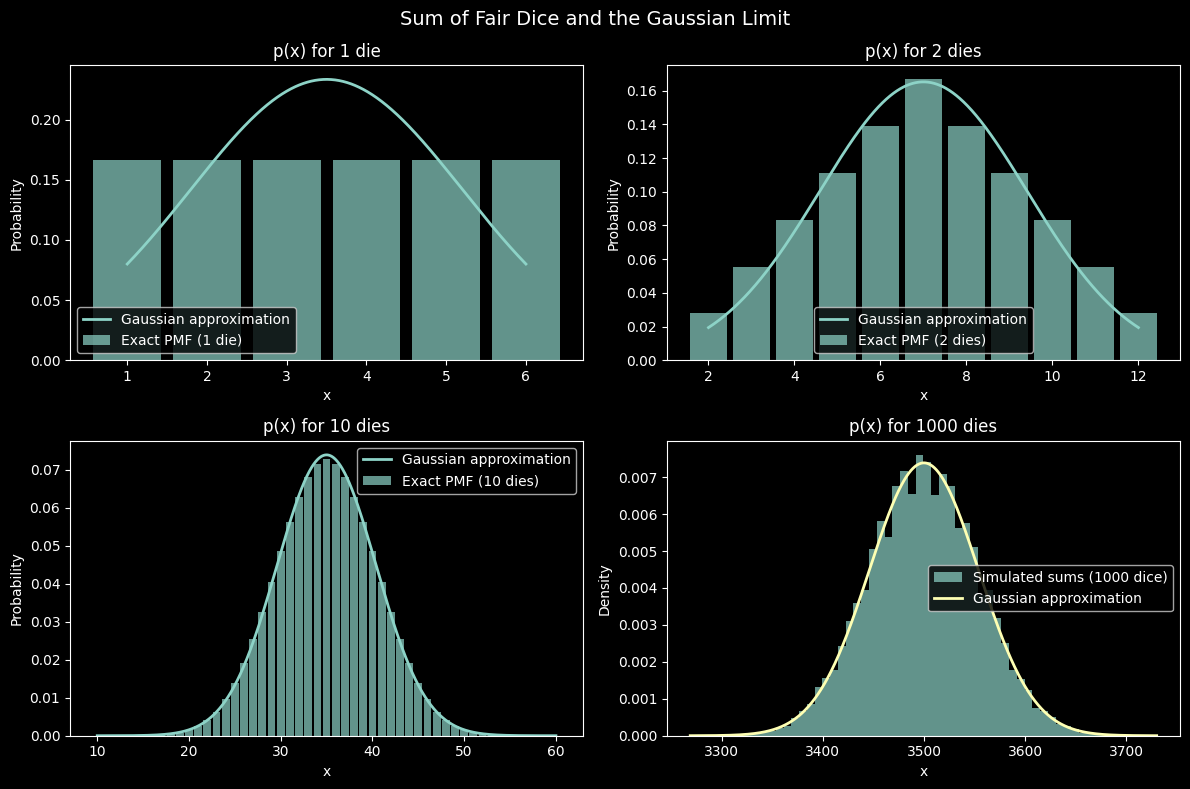

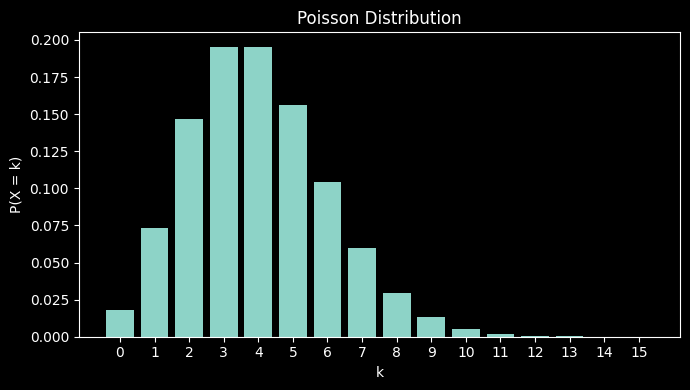

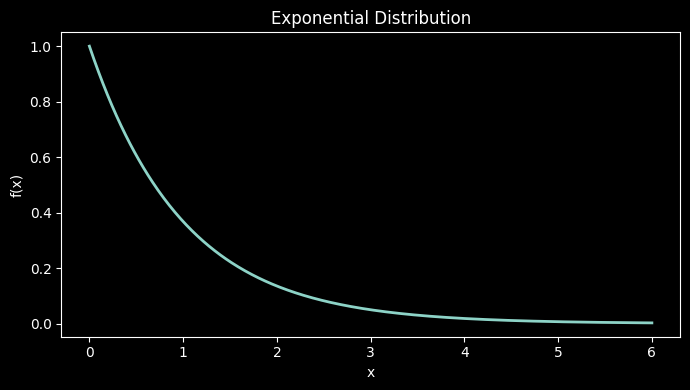

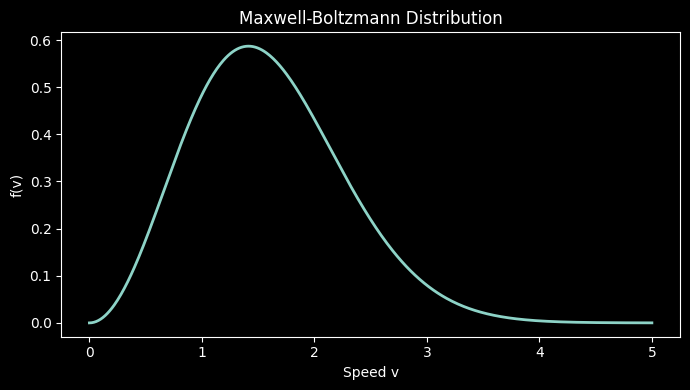

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import Counter


# --------------------------------------------------
# Helpers
# --------------------------------------------------
def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def convolve_dice_pmf(n_dice: int):
    """
    Exact PMF for the sum of n fair six-sided dice.
    Returns:
        sums: np.ndarray
        probs: np.ndarray
    """
    pmf = np.ones(6) / 6  # one die: outcomes 1..6
    for _ in range(n_dice - 1):
        pmf = np.convolve(pmf, np.ones(6) / 6)

    sums = np.arange(n_dice, 6 * n_dice + 1)
    return sums, pmf


# --------------------------------------------------
# 1) Gaussian / dice figures
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

dice_cases = [1, 2, 10, 1000]

for ax, n in zip(axes, dice_cases):
    mu = 3.5 * n
    sigma = np.sqrt((35 / 12) * n)  # variance of one die = 35/12

    if n <= 10:
        # Exact discrete PMF
        sums, probs = convolve_dice_pmf(n)
        ax.bar(sums, probs, width=0.85, alpha=0.7, label=f"Exact PMF ({n} die{'s' if n > 1 else ''})")

        # Overlay Gaussian approximation
        x = np.linspace(sums.min(), sums.max(), 1000)
        ax.plot(x, gaussian(x, mu, sigma), linewidth=2, label="Gaussian approximation")

    else:
        # For 1000 dice, simulate and show histogram
        rng = np.random.default_rng(42)
        n_samples = 50000
        rolls = rng.integers(1, 7, size=(n_samples, n))
        totals = rolls.sum(axis=1)

        ax.hist(
            totals,
            bins=60,
            density=True,
            alpha=0.7,
            label=f"Simulated sums ({n} dice)"
        )

        x = np.linspace(totals.min(), totals.max(), 1000)
        ax.plot(x, gaussian(x, mu, sigma), linewidth=2, label="Gaussian approximation")

    ax.set_title(f"p(x) for {n} die{'s' if n > 1 else ''}")
    ax.set_xlabel("x")
    ax.set_ylabel("Probability" if n <= 10 else "Density")
    ax.legend()

fig.suptitle("Sum of Fair Dice and the Gaussian Limit", fontsize=14)
fig.tight_layout()
plt.show()


# --------------------------------------------------
# 2) Poisson distribution figure
# --------------------------------------------------
lam = 4.0
k = np.arange(0, 16)
poisson_pmf = np.array([np.exp(-lam) * lam**ki / math.factorial(ki) for ki in k])

plt.figure(figsize=(7, 4))
plt.bar(k, poisson_pmf, width=0.8)
plt.title("Poisson Distribution")
plt.xlabel("k")
plt.ylabel("P(X = k)")
plt.xticks(k)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3) Exponential distribution figure
# --------------------------------------------------
rate = 1.0  # lambda
x = np.linspace(0, 6, 500)
exp_pdf = rate * np.exp(-rate * x)

plt.figure(figsize=(7, 4))
plt.plot(x, exp_pdf, linewidth=2)
plt.title("Exponential Distribution")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 4) Maxwell-Boltzmann distribution figure
# --------------------------------------------------
# Simple speed distribution shape:
# f(v) ∝ v^2 exp(-a v^2)
v = np.linspace(0, 5, 500)
a = 0.5
mb = v**2 * np.exp(-a * v**2)

# normalise numerically just to make the vertical axis cleaner
mb /= np.trapezoid(mb, v)

plt.figure(figsize=(7, 4))
plt.plot(v, mb, linewidth=2)
plt.title("Maxwell-Boltzmann Distribution")
plt.xlabel("Speed v")
plt.ylabel("f(v)")
plt.tight_layout()
plt.show()